In [2]:
import numpy as np
import matplotlib
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['lines.markersize'] = 100

plt.rcParams["font.family"] = "Arial"
plt.style.use('default')


In [3]:
a = np.load('results_nn_20250415/mlp/deployment_decision_20_set_10_dist_0.6.npy')
a.shape

(10, 20)

# NN

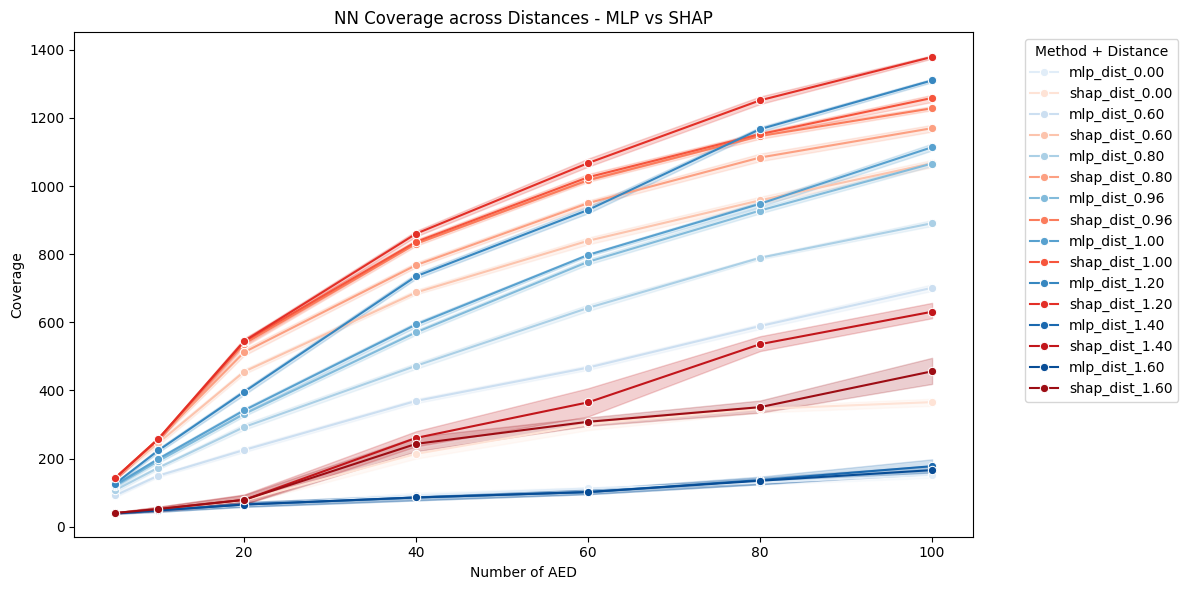

In [3]:
# 基本設定
# loc_num = [5, 10, 20, 40, 60, 80, 100]

dist_list = [0, 0.6, 0.8, 0.96, 1, 1.2, 1.4, 1.6]
loc_num = [5, 10, 20, 40, 60, 80, 100]
# dist_list = [0, 0.6, 0.8, 0.96, 1]
# loc_num = [5, 10, 20, 40, 60, 80, 100]

# 儲存所有資料的 DataFrame 列表
df_list_coverage = []

# 為每個 dist 計算 mlp 和 shap 結果
for dist in dist_list:
    for method in ['mlp', 'shap']:
        # 初始化儲存 coverage 的陣列
        coverage_array = np.zeros((len(loc_num), 10))
        
        for i, n in enumerate(loc_num):
            # 讀取對應檔案
            path = f'results_nn_20250415/{method}/deployment_decision_coverage_{n}_set_10_dist_{dist}.npy'
            coverage_array[i] = np.load(path)
        
        # 將轉置後的資料轉為 DataFrame（方便 melt）
        df_temp = pd.DataFrame(coverage_array.T, columns=loc_num).melt(
            var_name='AED_number', value_name='coverage'
        )
        df_temp['method'] = method
        df_temp['dist'] = dist
        df_list_coverage.append(df_temp)

# 合併所有資料
df_cov = pd.concat(df_list_coverage, ignore_index=True)

# 建立繪圖用的 legend 名稱：mlp_0.6、shap_1.0 等
df_cov['dist_str'] = df_cov['dist'].map(lambda x: f'{x:.2f}')
df_cov['legend'] = df_cov['method'] + '_dist_' + df_cov['dist_str']

# 設定顏色：mlp 用藍色系，shap 用紅色系
mlp_colors = sns.color_palette("Blues", n_colors=len(dist_list))
shap_colors = sns.color_palette("Reds", n_colors=len(dist_list))
palette = {}

for i, dist in enumerate(dist_list):
    dist_str = f'{dist:.2f}'
    palette[f'mlp_dist_{dist_str}'] = mlp_colors[i]
    palette[f'shap_dist_{dist_str}'] = shap_colors[i]

# 繪圖
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='AED_number',
    y='coverage',
    hue='legend',
    data=df_cov,
    palette=palette,
    marker='o'
)

# 設定標籤與圖例
plt.xlabel('Number of AED')
plt.ylabel('Coverage')
plt.title('NN Coverage across Distances - MLP vs SHAP')
plt.legend(title='Method + Distance', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

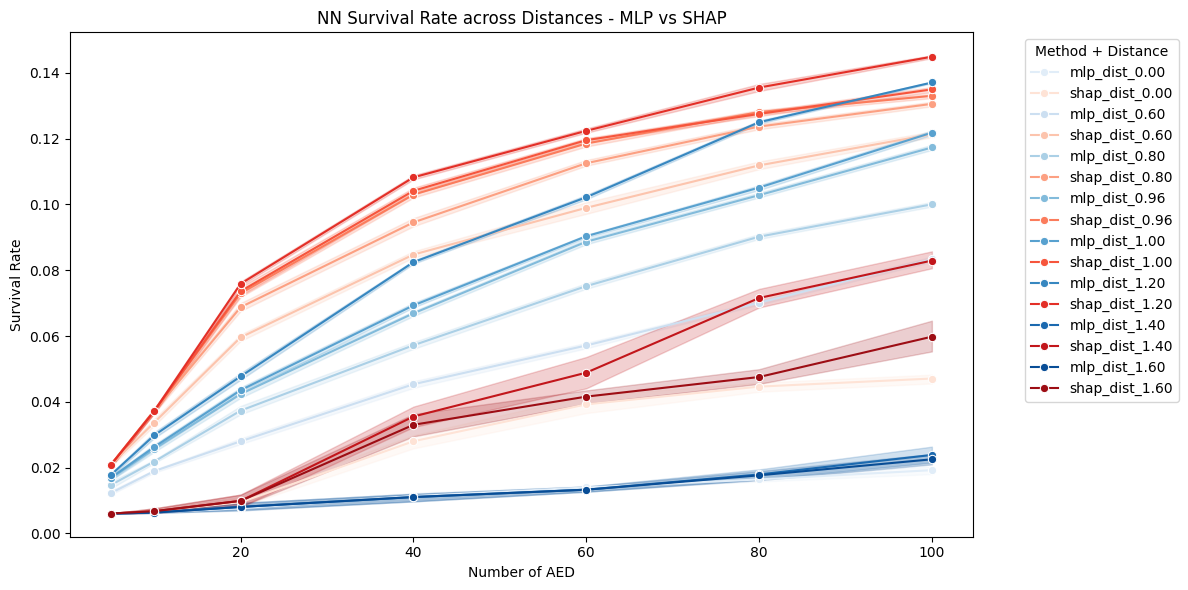

In [6]:
# 儲存所有資料的 DataFrame 列表
df_list_survival = []

# 為每個 dist 計算 mlp 和 shap 結果
for dist in dist_list:
    for method in ['mlp', 'shap']:
        # 初始化儲存 coverage 的陣列
        survival_array = np.zeros((len(loc_num), 10))
        
        for i, n in enumerate(loc_num):
            # 讀取對應檔案
            path = f'results_nn_20250415/{method}/deploy_decision_survivalrate_average_{n}_set_10_dist_{dist}.npy'
            survival_array[i] = np.load(path)
        
        # 將轉置後的資料轉為 DataFrame（方便 melt）
        df_temp = pd.DataFrame(survival_array.T, columns=loc_num).melt(
            var_name='AED_number', value_name='survival_rate'
        )
        df_temp['method'] = method
        df_temp['dist'] = dist
        df_list_survival.append(df_temp)

# 合併所有資料
df_sur = pd.concat(df_list_survival, ignore_index=True)

# 建立繪圖用的 legend 名稱：mlp_0.6、shap_1.0 等
df_sur['dist_str'] = df_sur['dist'].map(lambda x: f'{x:.2f}')
df_sur['legend'] = df_sur['method'] + '_dist_' + df_sur['dist_str']

# 設定顏色：mlp 用藍色系，shap 用紅色系
mlp_colors = sns.color_palette("Blues", n_colors=len(dist_list))
shap_colors = sns.color_palette("Reds", n_colors=len(dist_list))
palette = {}

for i, dist in enumerate(dist_list):
    dist_str = f'{dist:.2f}'
    palette[f'mlp_dist_{dist_str}'] = mlp_colors[i]
    palette[f'shap_dist_{dist_str}'] = shap_colors[i]

# 繪圖
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='AED_number',
    y='survival_rate',
    hue='legend',
    data=df_sur,
    palette=palette,
    marker='o'
)

# 設定標籤與圖例
plt.xlabel('Number of AED')
plt.ylabel('Survival Rate')
plt.title('NN Survival Rate across Distances - MLP vs SHAP')
plt.legend(title='Method + Distance', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

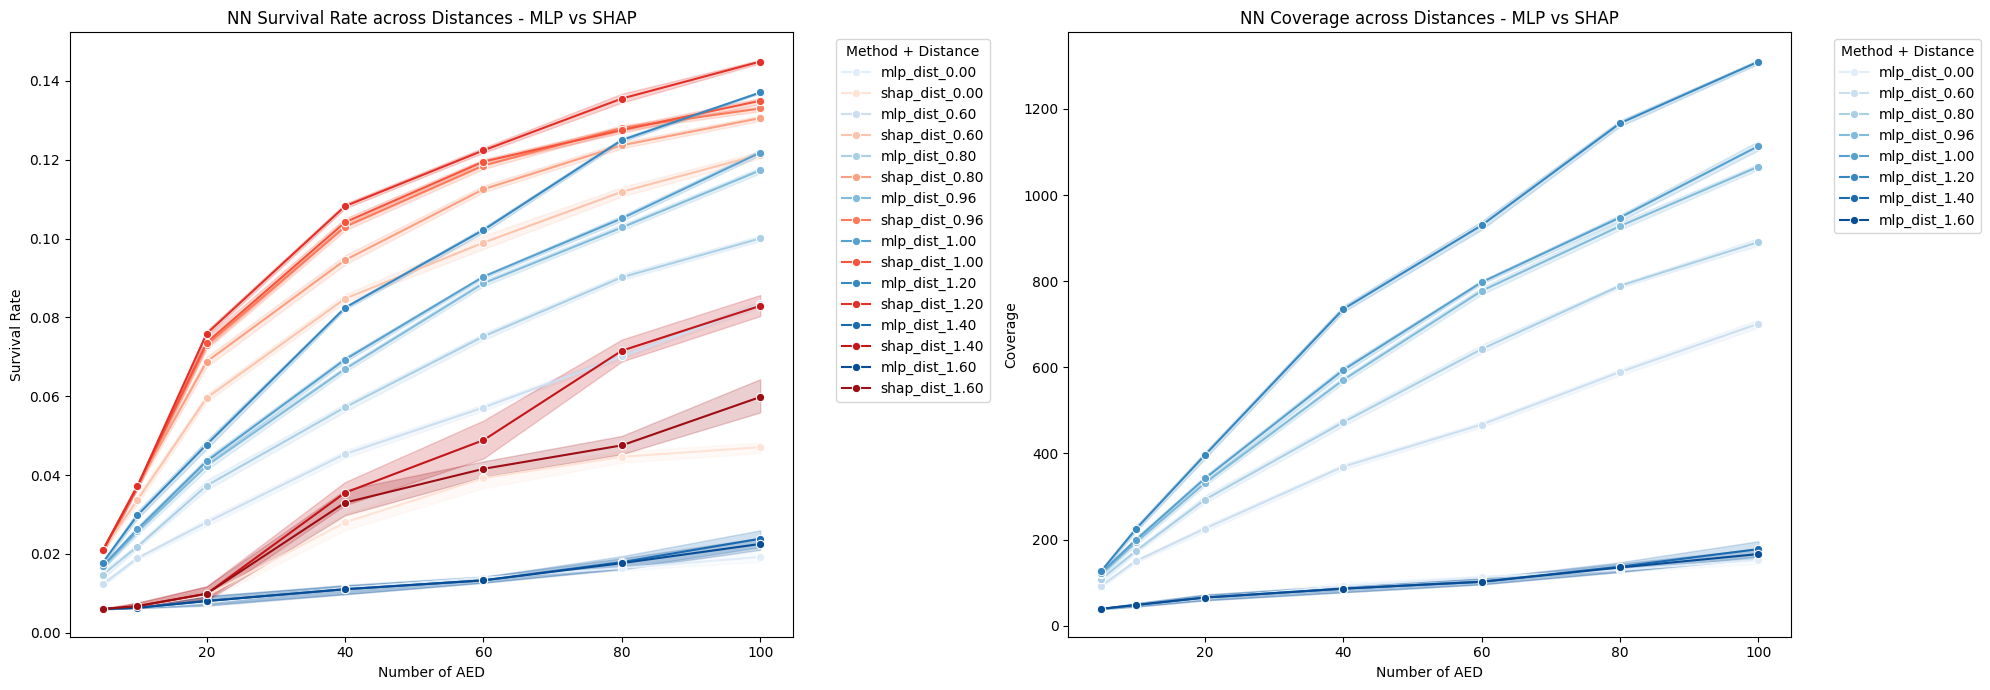

In [7]:
## 建立一個 1x2 的子圖，figsize 設定圖形大小
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
## 左圖：畫出 Survival Rate 線圖
sns.lineplot(ax=axes[0],
             x='AED_number', y='survival_rate', hue='legend', data=df_sur, palette=palette, marker='o')
axes[0].set_xlabel('Number of AED')  # X 軸標籤
axes[0].set_ylabel('Survival Rate')  # Y 軸標籤
axes[0].set_title('NN Survival Rate across Distances - MLP vs SHAP')  # 圖標題
axes[0].legend(title='Method + Distance', bbox_to_anchor=(1.05, 1), loc='upper left')  # 圖例
## 右圖：畫出 Coverage 線圖
sns.lineplot(ax=axes[1],
             x='AED_number', y='coverage', hue='legend', data=df_cov, palette=palette, marker='o')
axes[1].set_xlabel('Number of AED')  # X 軸標籤
axes[1].set_ylabel('Coverage')  # Y 軸標籤
axes[1].set_title('NN Coverage across Distances - MLP vs SHAP')  # 圖標題
axes[1].legend(title='Method + Distance', bbox_to_anchor=(1.05, 1), loc='upper left')  # 圖例
plt.tight_layout()  # 自動調整子圖間距
plt.show()  # 顯示圖形

# XGBoost

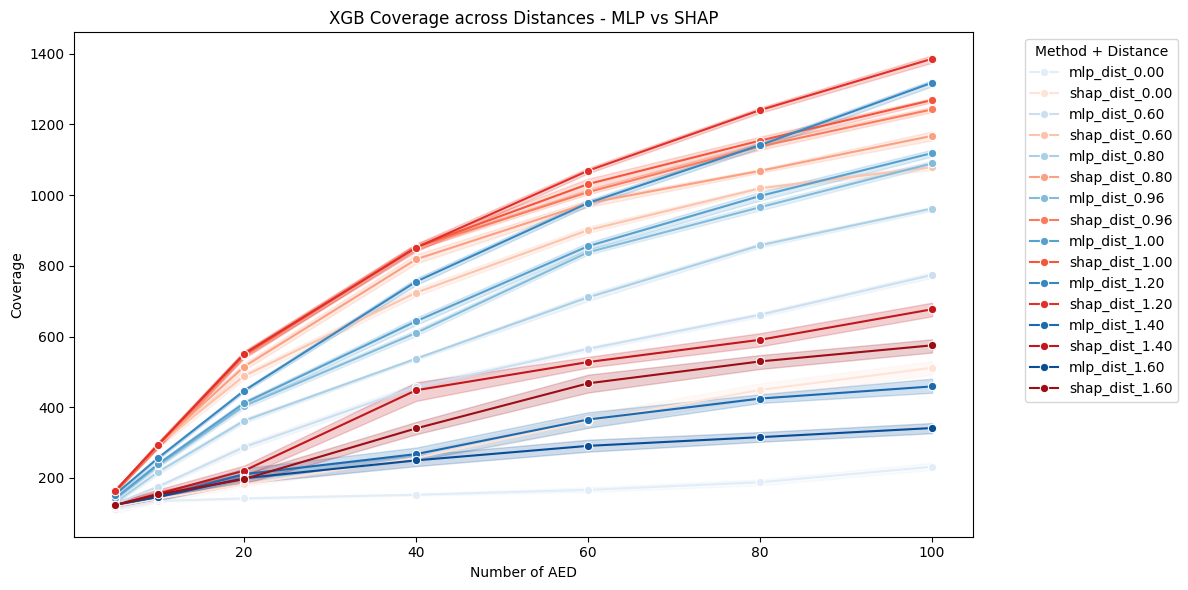

In [6]:
# 儲存所有資料的 DataFrame 列表
df_list_coverage = []

# 為每個 dist 計算 mlp 和 shap 結果
for dist in dist_list:
    for method in ['mlp', 'shap']:
        # 初始化儲存 coverage 的陣列
        coverage_array = np.zeros((len(loc_num), 10))
        
        for i, n in enumerate(loc_num):
            # 讀取對應檔案
            path = f'results_xgb_20250415/{method}/deployment_decision_coverage_{n}_set_10_dist_{dist}.npy'
            coverage_array[i] = np.load(path)
        
        # 將轉置後的資料轉為 DataFrame（方便 melt）
        df_temp = pd.DataFrame(coverage_array.T, columns=loc_num).melt(
            var_name='AED_number', value_name='coverage'
        )
        df_temp['method'] = method
        df_temp['dist'] = dist
        df_list_coverage.append(df_temp)

# 合併所有資料
df_cov = pd.concat(df_list_coverage, ignore_index=True)

# 建立繪圖用的 legend 名稱：mlp_0.6、shap_1.0 等
df_cov['dist_str'] = df_cov['dist'].map(lambda x: f'{x:.2f}')
df_cov['legend'] = df_cov['method'] + '_dist_' + df_cov['dist_str']

# 設定顏色：mlp 用藍色系，shap 用紅色系
mlp_colors = sns.color_palette("Blues", n_colors=len(dist_list))
shap_colors = sns.color_palette("Reds", n_colors=len(dist_list))
palette = {}

for i, dist in enumerate(dist_list):
    dist_str = f'{dist:.2f}'
    palette[f'mlp_dist_{dist_str}'] = mlp_colors[i]
    palette[f'shap_dist_{dist_str}'] = shap_colors[i]

# 繪圖
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='AED_number',
    y='coverage',
    hue='legend',
    data=df_cov,
    palette=palette,
    marker='o'
)

# 設定標籤與圖例
plt.xlabel('Number of AED')
plt.ylabel('Coverage')
plt.title('XGB Coverage across Distances - MLP vs SHAP')
plt.legend(title='Method + Distance', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

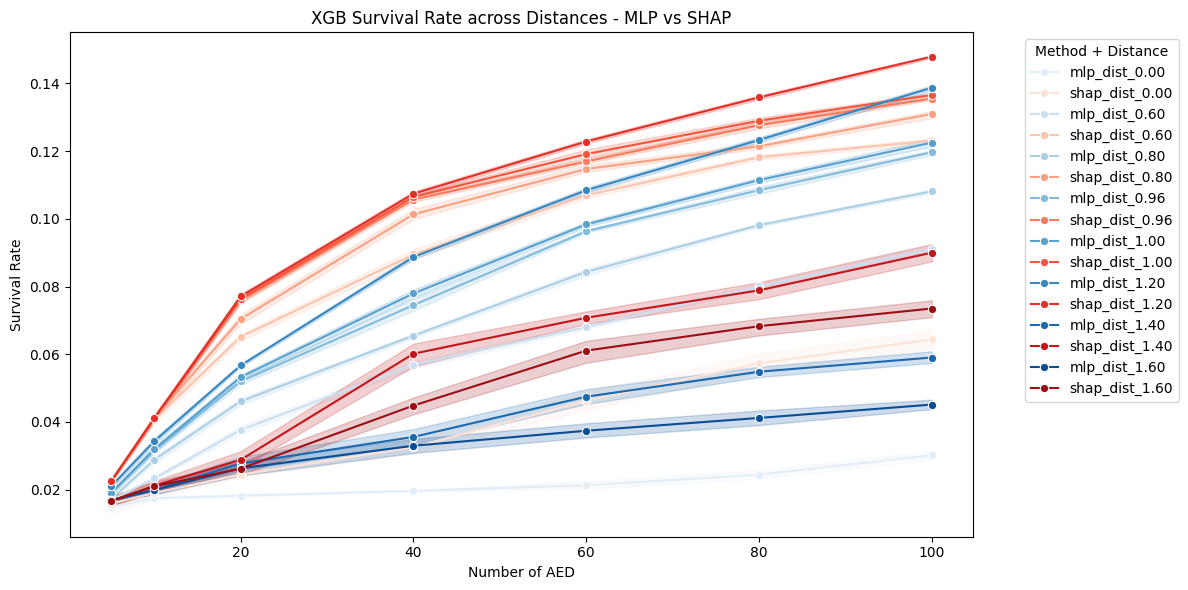

In [7]:
# 儲存所有資料的 DataFrame 列表
df_list_survival = []

# 為每個 dist 計算 mlp 和 shap 結果
for dist in dist_list:
    for method in ['mlp', 'shap']:
        # 初始化儲存 coverage 的陣列
        survival_array = np.zeros((len(loc_num), 10))
        
        for i, n in enumerate(loc_num):
            # 讀取對應檔案
            path = f'results_xgb_20250415/{method}/deploy_decision_survivalrate_average_{n}_set_10_dist_{dist}.npy'
            survival_array[i] = np.load(path)
        
        # 將轉置後的資料轉為 DataFrame（方便 melt）
        df_temp = pd.DataFrame(survival_array.T, columns=loc_num).melt(
            var_name='AED_number', value_name='survival_rate'
        )
        df_temp['method'] = method
        df_temp['dist'] = dist
        df_list_survival.append(df_temp)

# 合併所有資料
df_sur = pd.concat(df_list_survival, ignore_index=True)

# 建立繪圖用的 legend 名稱：mlp_0.6、shap_1.0 等
df_sur['dist_str'] = df_sur['dist'].map(lambda x: f'{x:.2f}')
df_sur['legend'] = df_sur['method'] + '_dist_' + df_sur['dist_str']

# 設定顏色：mlp 用藍色系，shap 用紅色系
mlp_colors = sns.color_palette("Blues", n_colors=len(dist_list))
shap_colors = sns.color_palette("Reds", n_colors=len(dist_list))
palette = {}

for i, dist in enumerate(dist_list):
    dist_str = f'{dist:.2f}'
    palette[f'mlp_dist_{dist_str}'] = mlp_colors[i]
    palette[f'shap_dist_{dist_str}'] = shap_colors[i]

# 繪圖
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='AED_number',
    y='survival_rate',
    hue='legend',
    data=df_sur,
    palette=palette,
    marker='o'
)

# 設定標籤與圖例
plt.xlabel('Number of AED')
plt.ylabel('Survival Rate')
plt.title('XGB Survival Rate across Distances - MLP vs SHAP')
plt.legend(title='Method + Distance', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

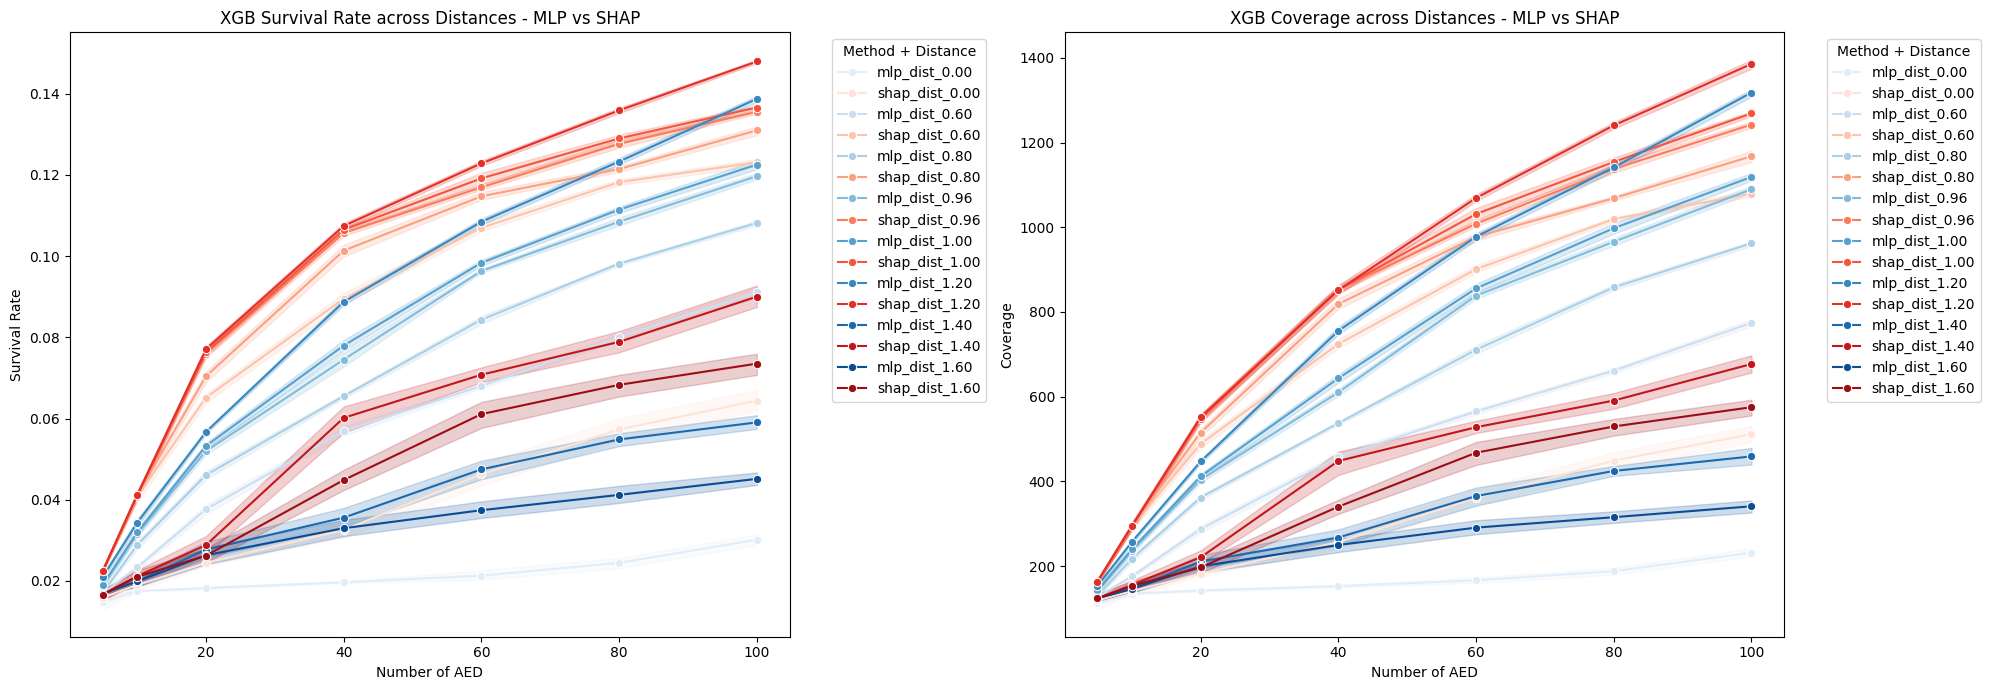

In [ ]:
## 建立一個 1x2 的子圖，figsize 設定圖形大小
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
## 左圖：畫出 Survival Rate 線圖
sns.lineplot(ax=axes[0],
             x='AED_number', y='survival_rate', hue='legend', data=df_sur, palette=palette, marker='o')
axes[0].set_xlabel('Number of AED')  # X 軸標籤
axes[0].set_ylabel('Survival Rate')  # Y 軸標籤
axes[0].set_title('XGB Survival Rate across Distances - MLP vs SHAP')  # 圖標題
axes[0].legend(title='Method + Distance', bbox_to_anchor=(1.05, 1), loc='upper left')  # 圖例
## 右圖：畫出 Coverage 線圖
sns.lineplot(ax=axes[1],
             x='AED_number', y='coverage', hue='legend', data=df_cov, palette=palette, marker='o')
axes[1].set_xlabel('Number of AED')  # X 軸標籤
axes[1].set_ylabel('Coverage')  # Y 軸標籤
axes[1].set_title('XGB Coverage across Distances - MLP vs SHAP')  # 圖標題
axes[1].legend(title='Method + Distance', bbox_to_anchor=(1.05, 1), loc='upper left')  # 圖例
plt.tight_layout()  # 自動調整子圖間距   排序 不要shap 和MLP相互排序 把 SHAP凸顯出來 可能用三角形 MLP改成虛線灰色
plt.show()  # 顯示圖形

# --------------------------------------------------------------

In [9]:
loc_num = [5, 10, 20, 40, 60, 80, 100]
deployment_survivalrate_average = np.zeros((7, 10))
for i in range(len(loc_num)):
    deployment_survivalrate_average[i] = np.load('correctv2/results_'+str(loc_num[i])+'/deploy_decision_survivalrate_average_'+str(loc_num[i])+'_set_10.npy')

loc_num = [5, 10, 20, 40, 60, 80, 100]
random_sr_average = np.zeros((7, 10))
for i in range(len(loc_num)):
    loc_coverage = np.load('results/random_choose_survivalrate_average_'+str(loc_num[i])+'_set_10.npy')
    random_sr_average[i] = loc_coverage[0] #np.average(loc_coverage, axis=1)

df = []
# for i in range(7):
df.append(pd.DataFrame(
                random_sr_average.T, columns = np.array(loc_num)
            ).melt(var_name='episode', value_name='return')
        )
df[0]['algo'] = 'random'
# for i in range(7):
df.append(pd.DataFrame(
                deployment_survivalrate_average.T, columns = np.array(loc_num)
            ).melt(var_name='episode', value_name='return')
        )
df[1]['algo'] = 'SIP'
df = pd.concat(df, ignore_index=True) 

sns.lineplot(x='episode', y='return', hue='algo', data=df, hue_order=['random', 'SIP'],
            #  palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#CC6600"],
            palette=["#E26464", "#649CCB"], #,  "#D79B00", "#1f77b4", "#FF9933"],
            markersize=10, legend='full')



plt.xlabel('Number of AED')
plt.ylabel('Average survival rate')
plt.title('Average Survival Rate - SIP Optimization v.s. Random Baseline')

FileNotFoundError: [Errno 2] No such file or directory: 'correctv2/results_5/deploy_decision_survivalrate_average_5_set_10.npy'

/home/dell/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dell/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dell/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dell/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

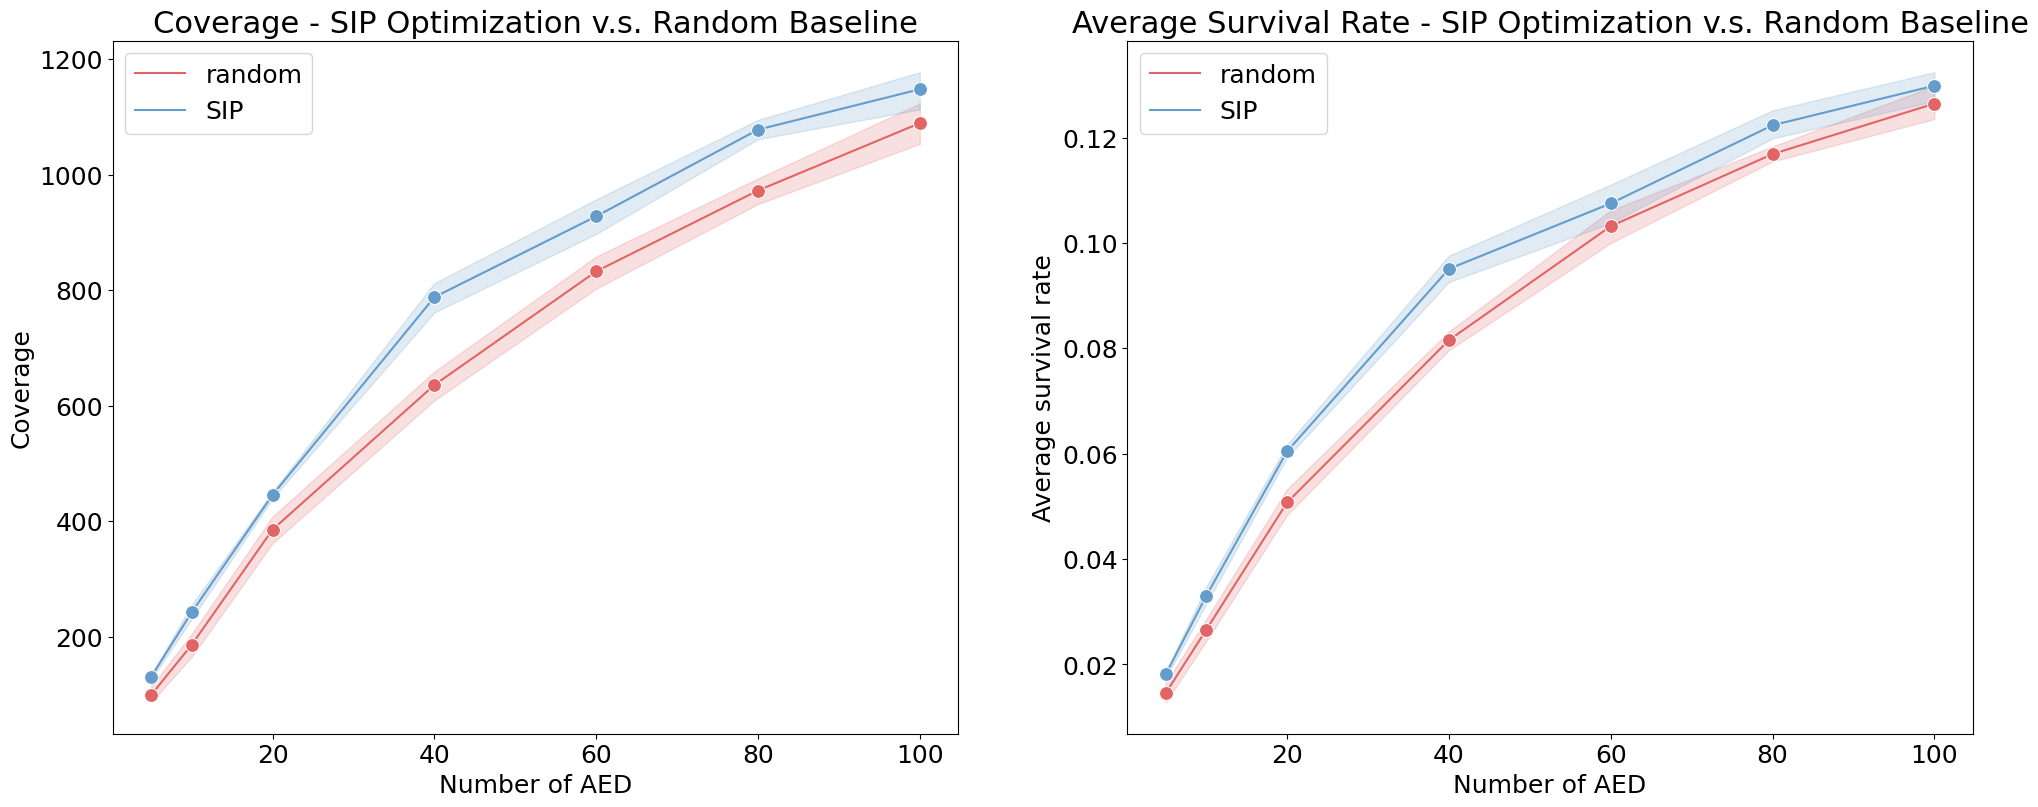

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24,9))
# fig.suptitle('Optimization effect of MIP model v.s. heuristic algorithm',fontsize=15)


loc_num = [5, 10, 20, 40, 60, 80, 100]
deployment_coverage_average = np.zeros((7, 10))
for i in range(len(loc_num)):
    deployment_coverage_average[i] = np.load('correctv2/results_'+str(loc_num[i])+'/deployment_decision_coverage_'+str(loc_num[i])+'_set_10.npy')


loc_num = [5, 10, 20, 40, 60, 80, 100]
random_coverage_average = np.zeros((7, 10))
for i in range(len(loc_num)):
    loc_coverage = np.load('results/random_choose_coverage_'+str(loc_num[i])+'_set_10.npy')
    random_coverage_average[i] = loc_coverage[0] #np.average(loc_coverage, axis=1)


df = []
df.append(pd.DataFrame(
                random_coverage_average.T, columns = np.array(loc_num)
            ).melt(var_name='episode', value_name='return')
        )
df[0]['legend'] = 'random'
df.append(pd.DataFrame(
                deployment_coverage_average.T, columns = np.array(loc_num)
            ).melt(var_name='episode', value_name='return')
        )
df[1]['legend'] = 'SIP'
df = pd.concat(df, ignore_index=True) 

sns.lineplot(ax=axes[0], data=df, x='episode', y='return', marker='o', 
             hue_order=['random', 'SIP'],
            #  palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#CC6600"],
            palette=["#E26464", "#649CCB",],#  "#D79B00", "#1f77b4", "#FF9933"],
             legend="auto", hue="legend", markersize=10)
# sns.lineplot(ax=axes[0], data=mip_vs_h, x="density", y="std_s_H", marker='s', color= "#E26464",
#              legend="full", label = 'heuristic', markersize=10)
axes[0].set_title('Coverage - SIP Optimization v.s. Random Baseline',fontsize=22)
# axes[0,0].set_xlabel('AED density',fontsize=28)
axes[0].set_xlabel('Number of AED',fontsize=18)
axes[0].set_ylabel('Coverage',fontsize=18)
axes[0].legend(fontsize=18
            #    , markerscale=2
               )
axes[0].tick_params(axis='both', labelsize=18)


#####################################################################


loc_num = [5, 10, 20, 40, 60, 80, 100]
deployment_survivalrate_average = np.zeros((7, 10))
for i in range(len(loc_num)):
    deployment_survivalrate_average[i] = np.load('correctv2/results_'+str(loc_num[i])+'/deploy_decision_survivalrate_average_'+str(loc_num[i])+'_set_10.npy')

loc_num = [5, 10, 20, 40, 60, 80, 100]
random_sr_average = np.zeros((7, 10))
for i in range(len(loc_num)):
    loc_sr_average = np.load('results/random_choose_survivalrate_average_'+str(loc_num[i])+'_set_10.npy')
    random_sr_average[i] = loc_sr_average[0] # np.average(loc_coverage, axis=1)

df = []
# for i in range(7):
df.append(pd.DataFrame(
                random_sr_average.T, columns = np.array(loc_num)
            ).melt(var_name='episode', value_name='return')
        )
df[0]['algo'] = 'random'
# for i in range(7):
df.append(pd.DataFrame(
                deployment_survivalrate_average.T, columns = np.array(loc_num)
            ).melt(var_name='episode', value_name='return')
        )
df[1]['algo'] = 'SIP'
df = pd.concat(df, ignore_index=True) 

sns.lineplot(ax=axes[1], data=df, x='episode', y='return', marker='o', 
            hue_order=['random', 'SIP'],
            palette=["#E26464", "#649CCB",],#  "#D79B00", "#1f77b4", "#FF9933"],
            legend="auto", hue="algo", markersize=10)

axes[1].set_title('Average Survival Rate - SIP Optimization v.s. Random Baseline',fontsize=22)
# axes[0,1].set_xlabel('AED density',fontsize=28)
axes[1].set_xlabel('Number of AED',fontsize=18)
axes[1].set_ylabel('Average survival rate',fontsize=18)
axes[1].tick_params(axis='both', labelsize=18)
axes[1].legend(fontsize=18)


In [ ]:
deployment_decision_100 = np.load('correctv2/results_100/deployment_decision_100_set_10.npy').astype(np.int64)[0]

In [ ]:
test_poi_df_total = pd.read_csv('test_poi_df_total.csv')

In [ ]:
candidate = np.load('build_num_choose_100_set_10.npy')[0]

In [ ]:
test_poi_df_total.iloc[deployment_decision_100]

,Unnamed: 0,osmid,lat,lon,h3_l7,building,score,total_score
524,524,10770522489,36.790890,-76.091723,872af6264ffffff,fountain,0.686314,12.236103
29099,29099,402372006,36.843181,-76.045570,872af6341ffffff,house,0.002507,2.688820
480,480,10039563540,36.800777,-76.190661,872af6276ffffff,police,-0.832500,11.848973
24595,24595,402285681,36.840377,-76.105251,872af635cffffff,commercial,0.030652,13.265169
6682,6682,402233163,36.881556,-76.147776,872af6356ffffff,house,0.004173,6.234059
...,...,...,...,...,...,...,...,...
17677,17677,402276087,36.823121,-76.095730,872af635dffffff,house,0.002251,12.221945
24410,24410,402285482,36.848384,-76.099688,872af6342ffffff,house,0.004321,6.916901
5023,5023,402218418,36.914231,-76.122708,872af6372ffffff,house,0.003471,6.604176
14646,14646,402257995,36.868598,-76.130403,872af6350ffffff,house,0.002517,16.807283


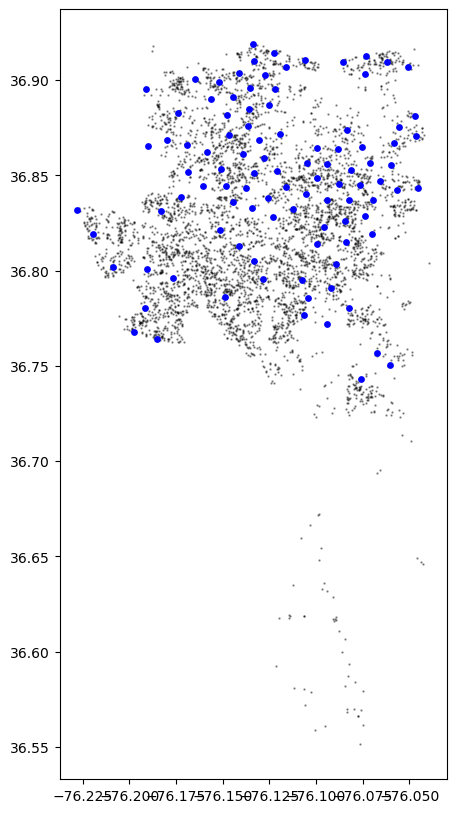

In [ ]:
plt.figure(figsize=(5, 10))
plt.scatter( test_poi_df_total.iloc[candidate].lon, test_poi_df_total.iloc[candidate].lat, c='black', s=0.5, alpha=0.4)
plt.scatter( test_poi_df_total.iloc[deployment_decision_100].lon, test_poi_df_total.iloc[deployment_decision_100].lat, marker='o', c='blue', s=15)

In [ ]:
random_coverage_average.shape, deployment_coverage_average.shape

((7, 10), (7, 10))

In [ ]:
random_coverage_average

array([[0.01457797, 0.01402261, 0.01459677, 0.01342708, 0.01410569,
        0.01295352, 0.01325077, 0.01509526, 0.01527457, 0.01381841],
       [0.02657483, 0.02753327, 0.02875857, 0.02590598, 0.0256849 ,
        0.02633118, 0.02835411, 0.02856768, 0.02635633, 0.0259017 ],
       [0.05076025, 0.05304168, 0.05062179, 0.04849972, 0.04785991,
        0.04824031, 0.0506249 , 0.04894294, 0.04990246, 0.04773729],
       [0.08155472, 0.08200719, 0.08013326, 0.08356436, 0.08018066,
        0.08158978, 0.08327456, 0.07918228, 0.08046523, 0.08050423],
       [0.10318437, 0.10168343, 0.10223473, 0.10078339, 0.10053334,
        0.10213611, 0.10552247, 0.1022489 , 0.10282425, 0.10213363],
       [0.11687773, 0.11587325, 0.11705373, 0.11402641, 0.11656898,
        0.1160469 , 0.11940816, 0.11669104, 0.11296701, 0.11967987],
       [0.12644808, 0.12793154, 0.12529759, 0.12892333, 0.12734639,
        0.12720078, 0.12388311, 0.1280895 , 0.1271384 , 0.12648479]])

/home/dell/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dell/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='episode', ylabel='return'>

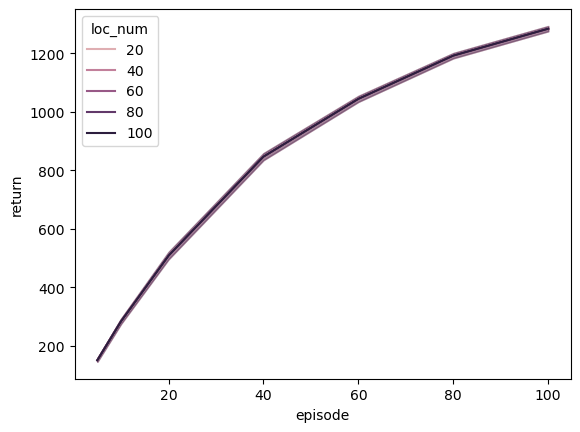

In [ ]:
df = []
for i in range(7):
    df.append(pd.DataFrame(
                    random_coverage_average.T, columns = np.array(loc_num)
                ).melt(var_name='episode', value_name='return')
            )
    df[i]['loc_num'] = loc_num[i]
df = pd.concat(df, ignore_index=True) 

sns.lineplot(x='episode', y='return', hue='loc_num', data=df)

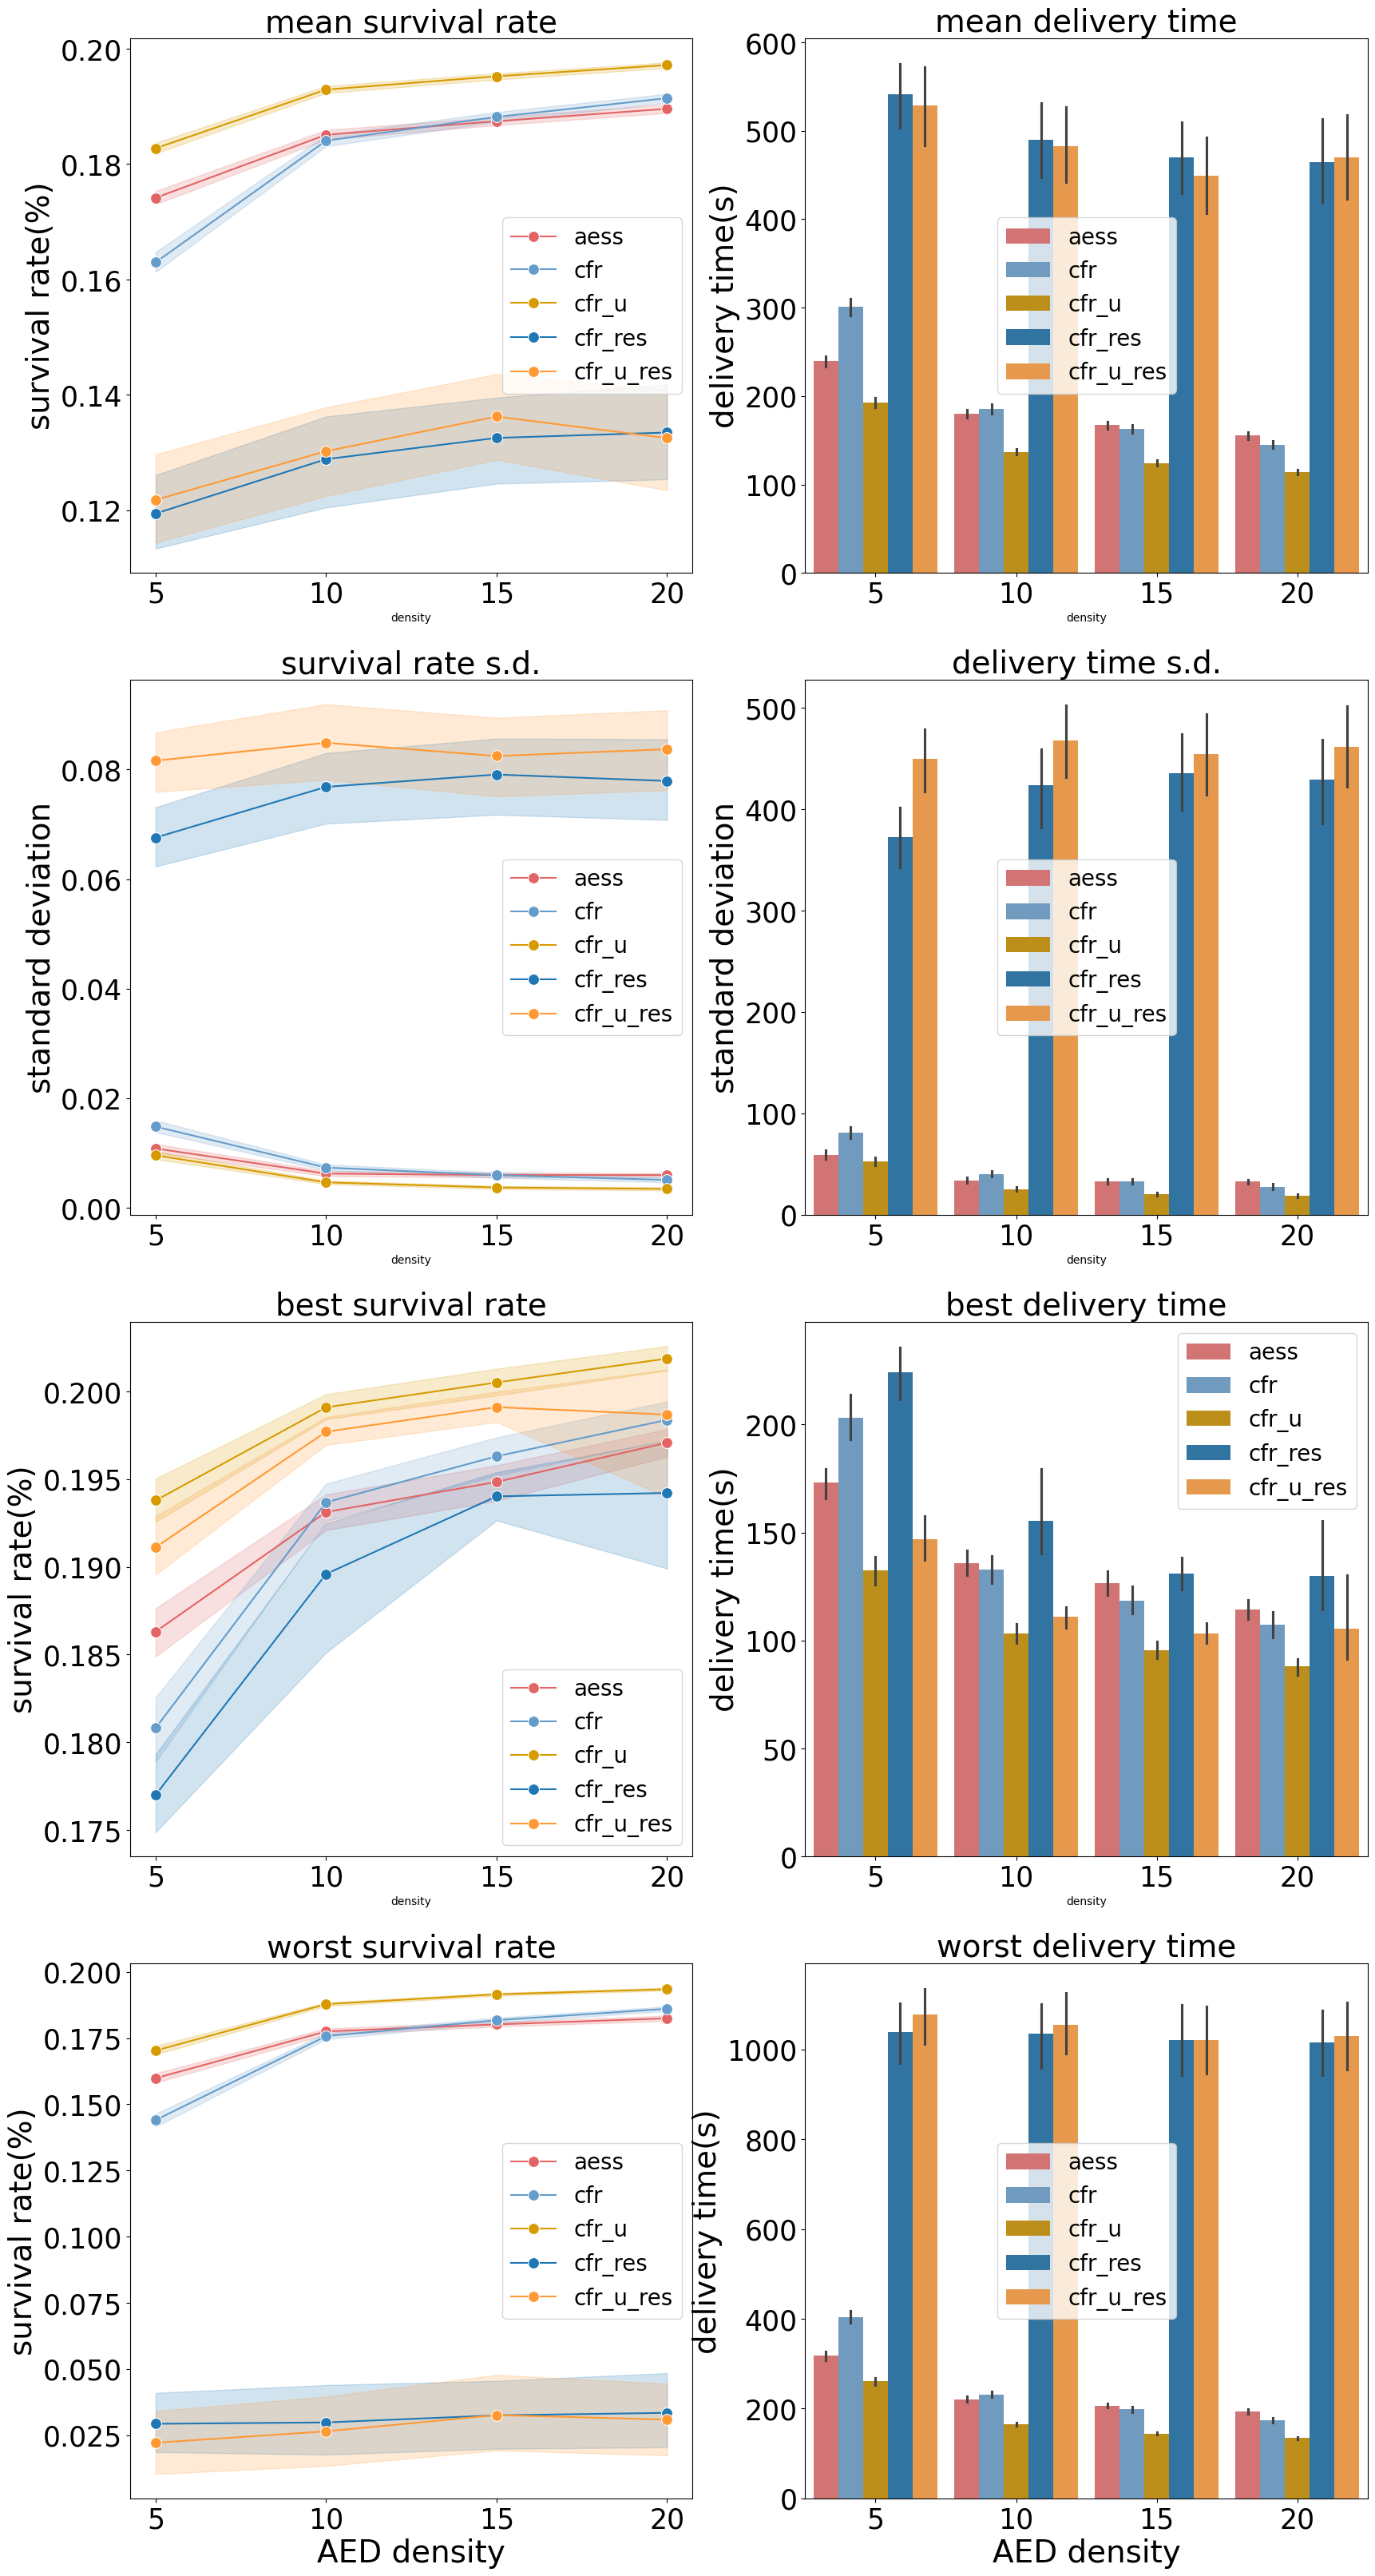

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(20,40))
# fig.suptitle('Optimization effect of MIP model v.s. heuristic algorithm',fontsize=15)
sns.lineplot(ax=axes[0,0], data=aess_vs_cfr, x="density", y="s_mean", marker='o', 
             hue_order=['aess','cfr','cfr_u','cfr_res','cfr_u_res'],
            #  palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#CC6600"],
            palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#FF9933"],
             legend="auto", hue="system", markersize=10)
# sns.lineplot(ax=axes[0], data=mip_vs_h, x="density", y="std_s_H", marker='s', color= "#E26464",
#              legend="full", label = 'heuristic', markersize=10)
axes[0,0].set_title('mean survival rate',fontsize=28)
# axes[0,0].set_xlabel('AED density',fontsize=28)
axes[0,0].set_ylabel('survival rate(%)',fontsize=28)
axes[0,0].legend(fontsize=20
            #    , markerscale=2
               )
axes[0,0].tick_params(axis='both', labelsize=25)
# axes[0,0].xaxis.set_ticks([5,10,15,20])
# axes[0,0].yaxis.set_ticks([0.004,0.006,0.008,0.010,0.012])

sns.barplot(ax=axes[0,1], data=aess_vs_cfr, x="density", y="t_mean", legend="full", 
            hue="system", hue_order=['aess','cfr','cfr_u','cfr_res','cfr_u_res'],
            # palette=["#E26464", "#649CCB",  "#D79B00", "#084A92", "#ff7f0e"],
            palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#FF9933"],
            # palette=["#8EA8CE", "#CD8886"], 
            # palette=["#6C8EBF", "#DE6560"],
            # palette=["#649CCB", "#E26464"],
            # palette=["#ff7f0e", "#1f77b4"],
            # palette=["#2979B9", "#F6553C"],
            width=0.88)
axes[0,1].set_title('mean delivery time',fontsize=28)
# axes[0,1].set_xlabel('AED density',fontsize=28)
axes[0,1].set_ylabel('delivery time(s)',fontsize=28)
axes[0,1].tick_params(axis='both', labelsize=25)
axes[0,1].legend(fontsize=20)
# axes[0,1].yaxis.set_ticks([0,15,30,45,60,75])

sns.lineplot(ax=axes[1,0], data=aess_vs_cfr, x="density", y="s_std", marker='o', 
             hue_order=['aess','cfr','cfr_u','cfr_res','cfr_u_res'],
            #  palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#CC6600"],
            palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#FF9933"],
             legend="full", hue="system", markersize=10)
# sns.lineplot(ax=axes[0], data=mip_vs_h, x="density", y="std_s_H", marker='s', color= "#E26464",
#              legend="full", label = 'heuristic', markersize=10)
axes[1,0].set_title('survival rate s.d.',fontsize=28)
# axes[0,0].set_xlabel('AED density',fontsize=28)
axes[1,0].set_ylabel('standard deviation',fontsize=28)
axes[1,0].legend(fontsize=20
            #    , markerscale=2
               )
axes[1,0].tick_params(axis='both', labelsize=25)
# axes[0,0].xaxis.set_ticks([5,10,15,20])
# axes[0,0].yaxis.set_ticks([0.004,0.006,0.008,0.010,0.012])

sns.barplot(ax=axes[1,1], data=aess_vs_cfr, x="density", y="t_std", legend="full", 
            hue="system", hue_order=['aess','cfr','cfr_u','cfr_res','cfr_u_res'],
            # palette=["#E26464", "#649CCB",  "#D79B00", "#084A92", "#ff7f0e"],
            palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#FF9933"],
            # palette=["#8EA8CE", "#CD8886"], 
            # palette=["#6C8EBF", "#DE6560"],
            # palette=["#649CCB", "#E26464"],
            # palette=["#ff7f0e", "#1f77b4"],
            # palette=["#2979B9", "#F6553C"],
            width=0.88)
axes[1,1].set_title('delivery time s.d.',fontsize=28)
# axes[0,1].set_xlabel('AED density',fontsize=28)
axes[1,1].set_ylabel('standard deviation',fontsize=28)
axes[1,1].tick_params(axis='both', labelsize=25)
axes[1,1].legend(fontsize=20)
# axes[0,1].yaxis.set_ticks([0,15,30,45,60,75])

sns.lineplot(ax=axes[2,0], data=aess_vs_cfr, x="density", y="s_best", marker='o', 
             hue_order=['aess','cfr','cfr_u','cfr_res','cfr_u_res'],
            #  palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#CC6600"],
            palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#FF9933"],
             legend="full", hue="system", markersize=10)
# sns.lineplot(ax=axes[0], data=mip_vs_h, x="density", y="std_s_H", marker='s', color= "#E26464",
#              legend="full", label = 'heuristic', markersize=10)
axes[2,0].set_title('best survival rate',fontsize=28)
# axes[0,0].set_xlabel('AED density',fontsize=28)
axes[2,0].set_ylabel('survival rate(%)',fontsize=28)
axes[2,0].legend(fontsize=20
            #    , markerscale=2
               )
axes[2,0].tick_params(axis='both', labelsize=25)
# axes[0,0].xaxis.set_ticks([5,10,15,20])
# axes[0,0].yaxis.set_ticks([0.004,0.006,0.008,0.010,0.012])

sns.barplot(ax=axes[2,1], data=aess_vs_cfr, x="density", y="t_best", legend="full", 
            hue="system", hue_order=['aess','cfr','cfr_u','cfr_res','cfr_u_res'],
            # palette=["#E26464", "#649CCB",  "#D79B00", "#084A92", "#ff7f0e"],
            palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#FF9933"],
            # palette=["#8EA8CE", "#CD8886"], 
            # palette=["#6C8EBF", "#DE6560"],
            # palette=["#649CCB", "#E26464"],
            # palette=["#ff7f0e", "#1f77b4"],
            # palette=["#2979B9", "#F6553C"],
            width=0.88)
axes[2,1].set_title('best delivery time',fontsize=28)
# axes[0,1].set_xlabel('AED density',fontsize=28)
axes[2,1].set_ylabel('delivery time(s)',fontsize=28)
axes[2,1].tick_params(axis='both', labelsize=25)
axes[2,1].legend(fontsize=20)
# axes[0,1].yaxis.set_ticks([0,15,30,45,60,75])

sns.lineplot(ax=axes[3,0], data=aess_vs_cfr, x="density", y="s_worst", marker='o', 
             hue_order=['aess','cfr','cfr_u','cfr_res','cfr_u_res'],
            #  palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#CC6600"],
            palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#FF9933"],
             legend="full", hue="system", markersize=10)
# sns.lineplot(ax=axes[0], data=mip_vs_h, x="density", y="std_s_H", marker='s', color= "#E26464",
#              legend="full", label = 'heuristic', markersize=10)
axes[3,0].set_title('worst survival rate',fontsize=28)
axes[3,0].set_xlabel('AED density',fontsize=28)
axes[3,0].set_ylabel('survival rate(%)',fontsize=28)
axes[3,0].legend(fontsize=20
            #    , markerscale=2
               )
axes[3,0].tick_params(axis='both', labelsize=25)
# axes[0,0].xaxis.set_ticks([5,10,15,20])
# axes[0,0].yaxis.set_ticks([0.004,0.006,0.008,0.010,0.012])

sns.barplot(ax=axes[3,1], data=aess_vs_cfr, x="density", y="t_worst", legend="full", 
            hue="system", hue_order=['aess','cfr','cfr_u','cfr_res','cfr_u_res'],
            # palette=["#E26464", "#649CCB",  "#D79B00", "#084A92", "#ff7f0e"],
            palette=["#E26464", "#649CCB",  "#D79B00", "#1f77b4", "#FF9933"],
            # palette=["#8EA8CE", "#CD8886"], 
            # palette=["#6C8EBF", "#DE6560"],
            # palette=["#649CCB", "#E26464"],
            # palette=["#ff7f0e", "#1f77b4"],
            # palette=["#2979B9", "#F6553C"],
            width=0.88)
axes[3,1].set_title('worst delivery time',fontsize=28)
axes[3,1].set_xlabel('AED density',fontsize=28)
axes[3,1].set_ylabel('delivery time(s)',fontsize=28)
axes[3,1].tick_params(axis='both', labelsize=25)
axes[3,1].legend(fontsize=20)
# axes[0,1].yaxis.set_ticks([0,15,30,45,60,75])

In [ ]:
mip_vs_h_hue

,density,survival rate,solving,delivery time,s_std,t_std
0,5,0.175884,MIP,230.144586,0.018458,100.864027
1,5,0.177575,MIP,220.900147,0.007284,39.802233
2,5,0.167803,MIP,274.303152,0.010300,56.284708
3,5,0.178114,MIP,217.955526,0.006906,37.737991
4,5,0.172310,MIP,249.669526,0.012895,70.463131
...,...,...,...,...,...,...
795,20,0.181056,heuristic,201.877793,0.007229,39.500456
796,20,0.179238,heuristic,211.812887,0.005549,30.324043
797,20,0.183196,heuristic,190.186448,0.012215,66.748256
798,20,0.191142,heuristic,146.766303,0.007183,39.252040


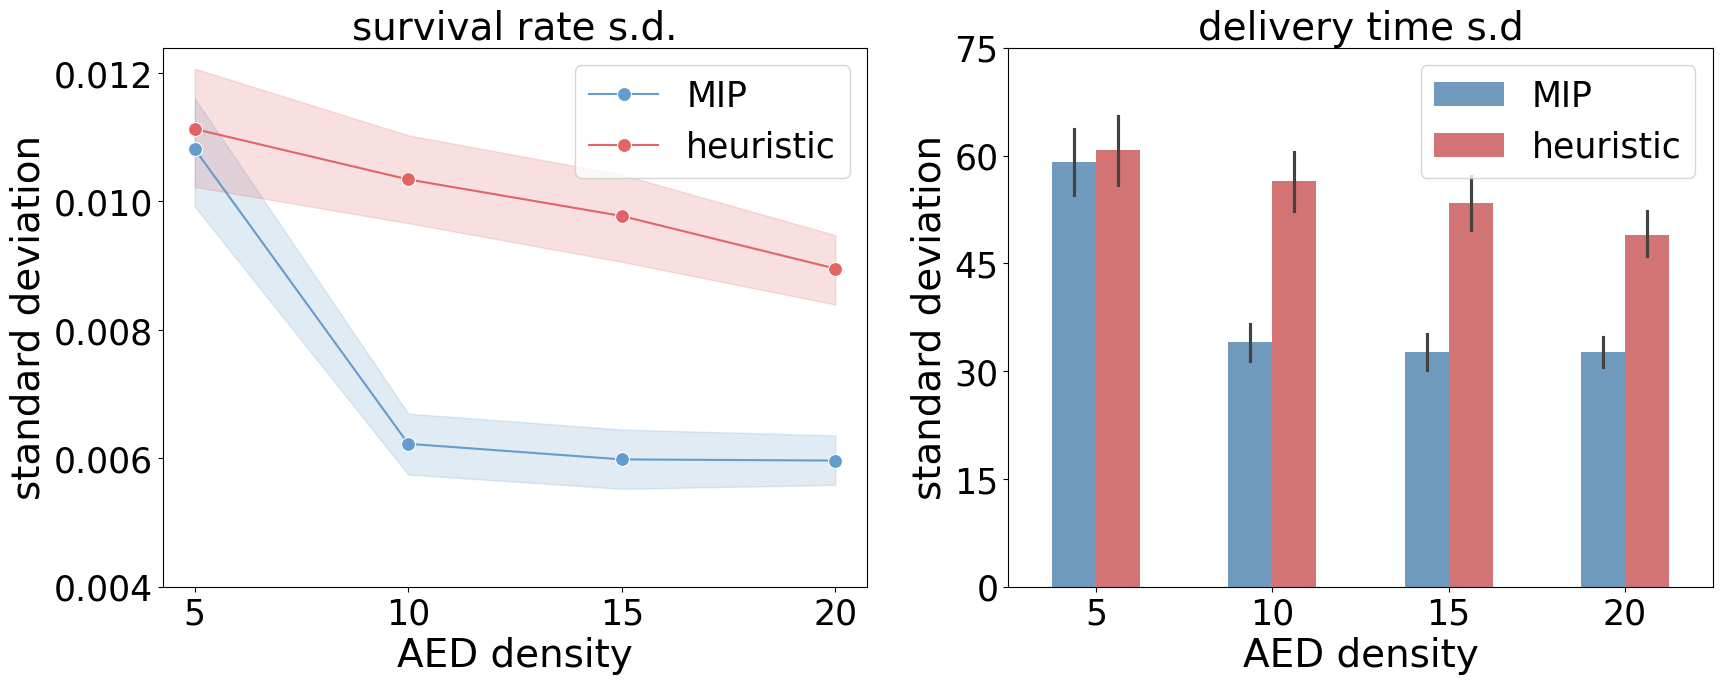

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20,7))
# fig.suptitle('Optimization effect of MIP model v.s. heuristic algorithm',fontsize=15)
sns.lineplot(ax=axes[0], data=mip_vs_h_hue, x="density", y="s_std", marker='o', palette=["#649CCB", "#E26464"],
             legend="full", hue="solving", markersize=10)
# sns.lineplot(ax=axes[0], data=mip_vs_h, x="density", y="std_s_H", marker='s', color= "#E26464",
#              legend="full", label = 'heuristic', markersize=10)
axes[0].set_title('survival rate s.d.',fontsize=28)
axes[0].set_xlabel('AED density',fontsize=28)
axes[0].set_ylabel('standard deviation',fontsize=28)
axes[0].legend(fontsize=25
            #    , markerscale=2
               )
axes[0].tick_params(axis='both', labelsize=25)
axes[0].xaxis.set_ticks([5,10,15,20])
axes[0].yaxis.set_ticks([0.004,0.006,0.008,0.010,0.012])

sns.barplot(ax=axes[1], data=mip_vs_h_hue, x="density", y="t_std", legend="full", hue="solving", 
            # palette=["#8EA8CE", "#CD8886"], 
            # palette=["#6C8EBF", "#DE6560"],
            palette=["#649CCB", "#E26464"],
            # palette=["#ff7f0e", "#1f77b4"],
            # palette=["#2979B9", "#F6553C"],
            width=0.5)
axes[1].set_title('delivery time s.d',fontsize=28)
axes[1].set_xlabel('AED density',fontsize=28)
axes[1].set_ylabel('standard deviation',fontsize=28)
axes[1].tick_params(axis='both', labelsize=25)
axes[1].legend(fontsize=25)
axes[1].yaxis.set_ticks([0,15,30,45,60,75])

plt.show()

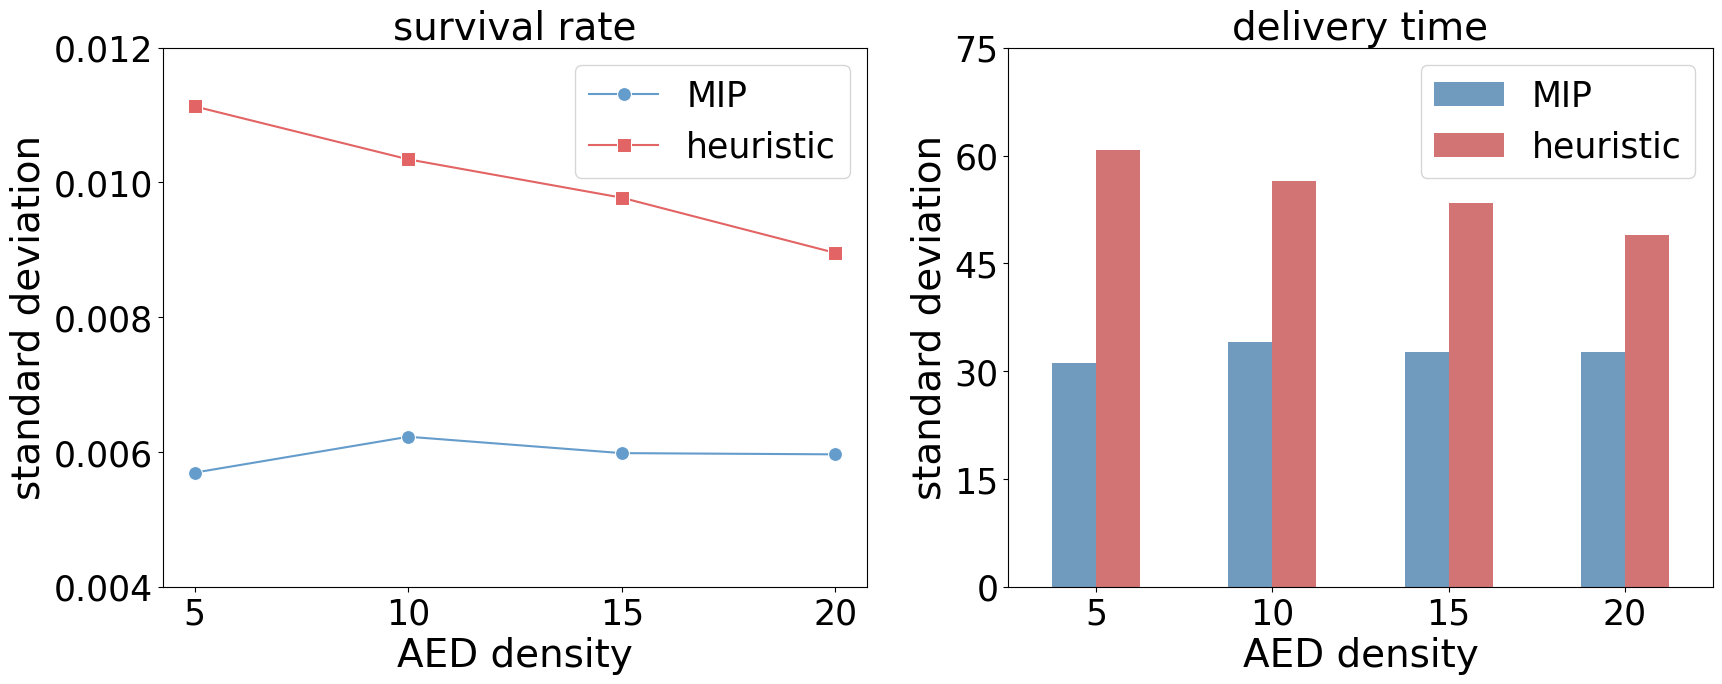

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20,7))
# fig.suptitle('Optimization effect of MIP model v.s. heuristic algorithm',fontsize=15)
sns.lineplot(ax=axes[0], data=mip_vs_h, x="density", y="std_s_MIP", marker='o', color= "#649CCB", 
             legend="full", label = 'MIP', markersize=10)
sns.lineplot(ax=axes[0], data=mip_vs_h, x="density", y="std_s_H", marker='s', color= "#E26464",
             legend="full", label = 'heuristic', markersize=10)
axes[0].set_title('survival rate',fontsize=28)
axes[0].set_xlabel('AED density',fontsize=28)
axes[0].set_ylabel('standard deviation',fontsize=28)
axes[0].legend(fontsize=25
            #    , markerscale=2
               )
axes[0].tick_params(axis='both', labelsize=25)
axes[0].xaxis.set_ticks([5,10,15,20])
axes[0].yaxis.set_ticks([0.004,0.006,0.008,0.010,0.012])

sns.barplot(ax=axes[1], data=mip_vs_h_std, x="density", y="std_t", legend="full", hue="solving", 
            # palette=["#8EA8CE", "#CD8886"], 
            # palette=["#6C8EBF", "#DE6560"],
            palette=["#649CCB", "#E26464"],
            # palette=["#ff7f0e", "#1f77b4"],
            # palette=["#2979B9", "#F6553C"],
            width=0.5)
axes[1].set_title('delivery time',fontsize=28)
axes[1].set_xlabel('AED density',fontsize=28)
axes[1].set_ylabel('standard deviation',fontsize=28)
axes[1].tick_params(axis='both', labelsize=25)
axes[1].legend(fontsize=25)
axes[1].yaxis.set_ticks([0,15,30,45,60,75])

plt.show()